In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('OneDrive/Desktop/FMCG_Project/outputs/retail_clean.csv')
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(f"Rows: {len(df):,}")
print(f"Date range: {df['invoicedate'].min().date()} → {df['invoicedate'].max().date()}")

Rows: 805,549
Date range: 2009-12-01 → 2011-12-09


In [2]:
# Cohort = the month of a customer's very first purchase
df['order_month'] = df['invoicedate'].dt.to_period('M')

cohort_map = df.groupby('customer_id')['order_month'].min().reset_index()
cohort_map.columns = ['customer_id', 'cohort_month']

# Merge back onto main dataframe
df = df.merge(cohort_map, on='customer_id', how='left')

print(df[['customer_id', 'invoicedate', 'order_month', 'cohort_month']].head(8))
print(f"\nUnique cohorts: {df['cohort_month'].nunique()}")

   customer_id         invoicedate order_month cohort_month
0        13085 2009-12-01 07:45:00     2009-12      2009-12
1        13085 2009-12-01 07:45:00     2009-12      2009-12
2        13085 2009-12-01 07:45:00     2009-12      2009-12
3        13085 2009-12-01 07:45:00     2009-12      2009-12
4        13085 2009-12-01 07:45:00     2009-12      2009-12
5        13085 2009-12-01 07:45:00     2009-12      2009-12
6        13085 2009-12-01 07:45:00     2009-12      2009-12
7        13085 2009-12-01 07:45:00     2009-12      2009-12

Unique cohorts: 25


In [3]:
# Month number since first purchase (0 = first purchase month)
df['cohort_index'] = (
    df['order_month'].dt.year * 12 + df['order_month'].dt.month
) - (
    df['cohort_month'].dt.year * 12 + df['cohort_month'].dt.month
)

print(df[['customer_id', 'order_month', 'cohort_month', 'cohort_index']].head(10))
print(f"\nMax cohort index: {df['cohort_index'].max()} months")

   customer_id order_month cohort_month  cohort_index
0        13085     2009-12      2009-12             0
1        13085     2009-12      2009-12             0
2        13085     2009-12      2009-12             0
3        13085     2009-12      2009-12             0
4        13085     2009-12      2009-12             0
5        13085     2009-12      2009-12             0
6        13085     2009-12      2009-12             0
7        13085     2009-12      2009-12             0
8        13085     2009-12      2009-12             0
9        13085     2009-12      2009-12             0

Max cohort index: 24 months


In [4]:
# Count unique customers per cohort per month
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'cohort_index', 'customers']

# Pivot into matrix form
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customers'
)

# Cohort sizes (column 0 = everyone who joined that month)
cohort_sizes = cohort_pivot[0]

# Retention rate = customers in month N / cohort size
retention = cohort_pivot.divide(cohort_sizes, axis=0).round(3)

print("Cohort sizes (customers acquired per month):")
print(cohort_sizes)

Cohort sizes (customers acquired per month):
cohort_month
2009-12    955.0
2010-01    383.0
2010-02    374.0
2010-03    443.0
2010-04    294.0
2010-05    254.0
2010-06    270.0
2010-07    186.0
2010-08    162.0
2010-09    243.0
2010-10    377.0
2010-11    325.0
2010-12     76.0
2011-01     71.0
2011-02    124.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    108.0
2011-07    102.0
2011-08    106.0
2011-09    189.0
2011-10    221.0
2011-11    191.0
2011-12     28.0
Freq: M, Name: 0, dtype: float64


In [5]:
print(retention.shape)  # will show more than 13 columns
print(retention.columns.tolist())  # you'll see month_0 to month_24

(25, 25)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [6]:
# Show first 6 months of retention for readability
print("Retention matrix (first 8 months):")
print((retention.iloc[:, :8] * 100).round(1).to_string())

Retention matrix (first 8 months):
cohort_index      0     1     2     3     4     5     6     7
cohort_month                                                 
2009-12       100.0  35.3  33.4  42.5  38.0  35.9  37.7  34.2
2010-01       100.0  20.6  31.1  30.5  26.4  30.0  25.8  23.0
2010-02       100.0  23.8  22.5  29.1  24.6  20.1  19.3  28.6
2010-03       100.0  19.0  23.0  24.2  23.3  20.3  24.6  30.2
2010-04       100.0  19.4  19.4  16.3  18.4  22.4  27.6  26.2
2010-05       100.0  15.7  16.9  17.3  17.7  25.6  21.3  12.6
2010-06       100.0  17.4  18.9  20.4  23.0  28.5  12.6   8.9
2010-07       100.0  15.6  18.3  29.6  29.0  14.0  11.3  14.5
2010-08       100.0  20.4  29.6  32.1  17.3  11.7   9.9  12.3
2010-09       100.0  22.6  23.5  12.3   9.1  10.3  13.6   9.9
2010-10       100.0  25.7  14.6  12.5   8.8   8.2  13.0  13.8
2010-11       100.0  17.5   9.2   9.5   7.7   8.6  12.9   9.8
2010-12       100.0   9.2   5.3   9.2  11.8   6.6   5.3   9.2
2011-01       100.0  16.9  21.1  19

In [7]:
# Save retention matrix (for the heatmap in Power BI)
retention_export = retention.copy()
retention_export.index = retention_export.index.astype(str)
retention_export.columns = [f'month_{int(c)}' for c in retention_export.columns]
retention_export.reset_index(inplace=True)
retention_export.rename(columns={'cohort_month': 'cohort_month'}, inplace=True)
retention_export.to_csv('OneDrive/Desktop/FMCG_Project/outputs/cohort_retention.csv', index=False)

# Save long format (more flexible for Power BI)
cohort_long = cohort_data.copy()
cohort_long['cohort_month'] = cohort_long['cohort_month'].astype(str)
cohort_long['retention_rate'] = (
    cohort_long.groupby('cohort_month')['customers']
    .transform(lambda x: x / x.iloc[0])
).round(3)
cohort_long.to_csv('OneDrive/Desktop/FMCG_Project/outputs/cohort_long.csv', index=False)

print("✓ Saved cohort_retention.csv")
print("✓ Saved cohort_long.csv")
print(f"\nCohort matrix shape: {retention.shape}")

✓ Saved cohort_retention.csv
✓ Saved cohort_long.csv

Cohort matrix shape: (25, 25)


In [8]:
# Average Month-1 retention (how many come back after first purchase)
month1_retention = retention[1].dropna().mean() * 100
month3_retention = retention[3].dropna().mean() * 100
month6_retention = retention[6].dropna().mean() * 100

print("=== KEY RETENTION METRICS ===")
print(f"Avg Month-1 retention: {month1_retention:.1f}%")
print(f"Avg Month-3 retention: {month3_retention:.1f}%")
print(f"Avg Month-6 retention: {month6_retention:.1f}%")

# Best and worst cohorts at Month 3
print(f"\nBest cohort at Month 3:  {(retention[3].idxmax())} — {retention[3].max()*100:.1f}%")
print(f"Worst cohort at Month 3: {(retention[3].idxmin())} — {retention[3].min()*100:.1f}%")

=== KEY RETENTION METRICS ===
Avg Month-1 retention: 21.2%
Avg Month-3 retention: 21.6%
Avg Month-6 retention: 17.8%

Best cohort at Month 3:  2009-12 — 42.5%
Worst cohort at Month 3: 2010-12 — 9.2%


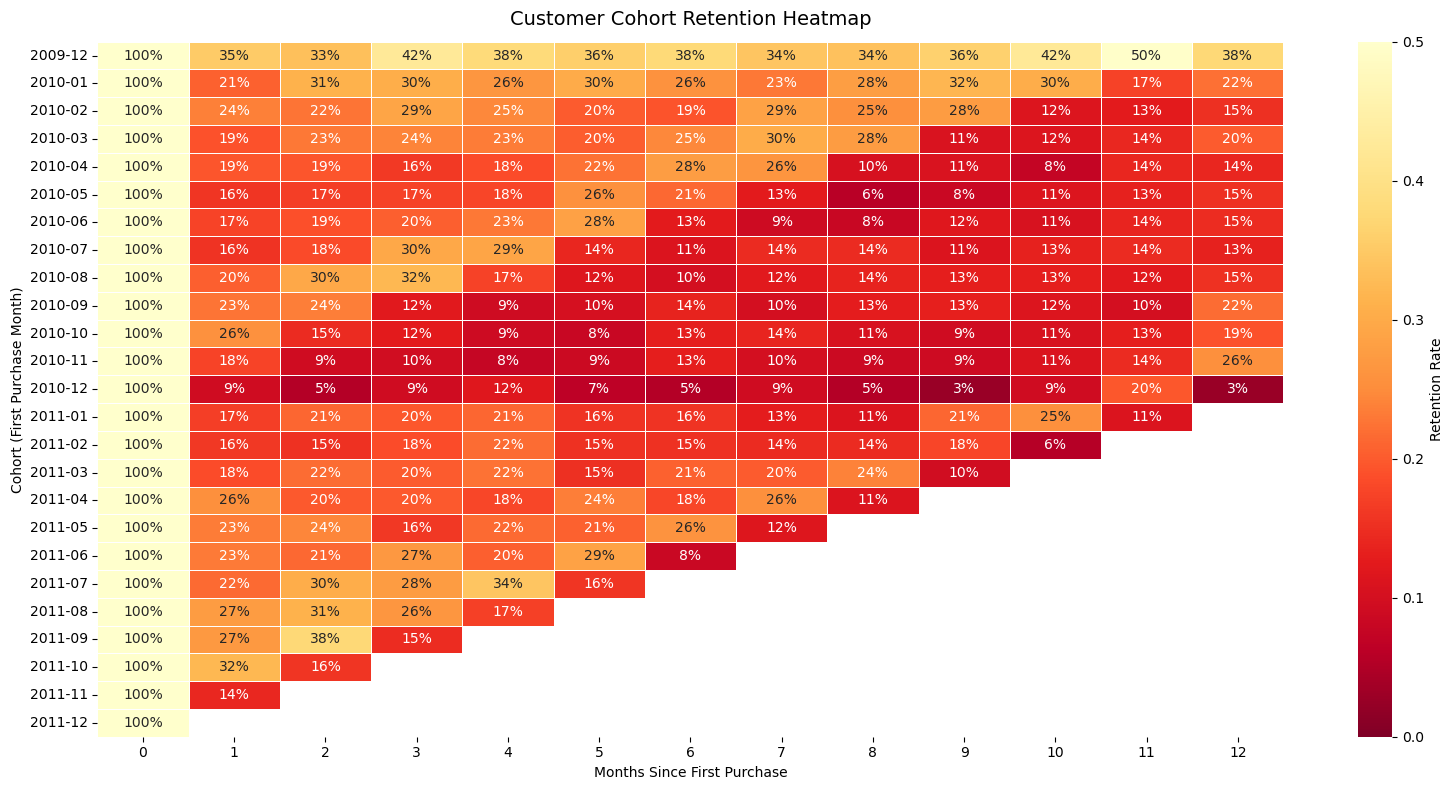

✓ Saved cohort_heatmap.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8))

sns.heatmap(
    retention.iloc[:, :13],        # first 12 months
    annot=True,
    fmt='.0%',
    cmap='YlOrRd_r',               # green = good retention, red = low
    vmin=0, vmax=0.5,
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)

plt.title('Customer Cohort Retention Heatmap', fontsize=14, pad=12)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('OneDrive/Desktop/FMCG_Project/outputs/cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved cohort_heatmap.png")